# Gold Layer - Customer Churn Prediction Model

**Final Client-Deliverable Model** for 3-class churn prediction.

## Target Variable (3 Classes)
| Class | Label | Definition |
|-------|-------|------------|
| 0 | **No Churn** | No retention cases resulted in 'Customer Lost' |
| 1 | **Partial Churn** | Some (not all) retention cases = 'Customer Lost' |
| 2 | **Full Churn** | All retention cases = 'Customer Lost' |

## Features
Customer-level aggregates from BoB data (no data leakage):
- Financial: revenue, fees, product value, unit amounts
- Agreement: count, types, branches, products, duration
- Behavioral: BoB ratio, retention case count

## Models
Logistic Regression, Random Forest, Gradient Boosting, SVM

---
# 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib.util, sys
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load custom modules
module_paths = {
    'model_preprocessing': '../../src/models/model_preprocessing.py',
    'model_training': '../../src/models/model_training.py',
    'model_evaluation': '../../src/models/model_evaluation.py',
}
loaded = {}
for name, path in module_paths.items():
    spec = importlib.util.spec_from_file_location(f'src.{name}', path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f'src.{name}'] = mod
    spec.loader.exec_module(mod)
    loaded[name] = mod

preprocess = loaded['model_preprocessing']
training = loaded['model_training']
evaluation = loaded['model_evaluation']
print('Gold layer modules loaded.')

Gold layer modules loaded.


---
# 2. Load & Prepare Data

In [2]:
df = preprocess.load_modeling_data('../../data/03_processed/analysis_data.csv')
display(df.head())

Loaded modeling data: (23772, 20)
Columns: ['account_number', 'total_revenue', 'avg_revenue', 'total_product_value', 'total_fees', 'avg_fees', 'avg_unit_amount', 'max_unit_amount', 'num_agreements', 'num_branches', 'num_agreement_types', 'num_products', 'avg_agreement_duration', 'max_agreement_duration', 'bob_ratio', 'num_retention_cases', 'dominant_agreement_type', 'revenue_per_agreement', 'fee_to_revenue_ratio', 'churn_category']


,account_number,total_revenue,avg_revenue,total_product_value,total_fees,avg_fees,avg_unit_amount,max_unit_amount,num_agreements,num_branches,num_agreement_types,num_products,avg_agreement_duration,max_agreement_duration,bob_ratio,num_retention_cases,dominant_agreement_type,revenue_per_agreement,fee_to_revenue_ratio,churn_category
0,GBA221737,8680.10,8680.1000,8680.10,0.00,0.00,39.81,39.81,1,1,1,0,365.00,365,1.0,0,Scheduled Billing,8680.100,0.000000,no_churn
1,UK02-000167723,3616.75,1808.3750,3616.75,0.00,0.00,39.81,39.81,2,1,1,0,1096.00,1096,1.0,0,Scheduled Billing,1808.375,0.000000,no_churn
2,UK02-000167746,2999.99,2999.9900,2840.03,159.96,159.96,236.67,236.67,1,1,1,1,730.00,730,1.0,0,Scheduled Billing,2999.990,0.053320,no_churn
3,UK02-000167747,2540.14,2540.1400,2540.14,0.00,0.00,39.81,39.81,1,1,1,0,365.00,365,1.0,0,Scheduled Billing,2540.140,0.000000,no_churn
4,UK02-000167753,18566.97,4641.7425,17692.05,874.92,218.73,288.24,390.77,1,1,1,1,1096.75,1097,1.0,0,Scheduled Billing,18566.970,0.047122,no_churn



--- Target Distribution ---
  0 (       no_churn):  22370 (94.1%)
  1 (  partial_churn):   1067 (4.5%)
  2 (     full_churn):    335 (1.4%)


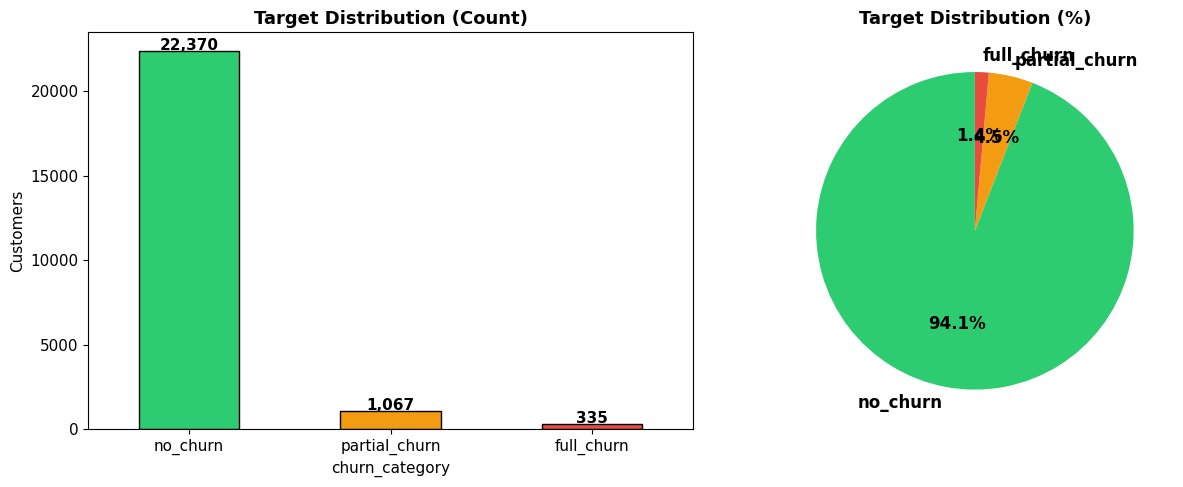

In [3]:
# Encode 3-class target
df, label_mapping = preprocess.encode_target(df, target_col='churn_category')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
order = ['no_churn', 'partial_churn', 'full_churn']
dist = df['churn_category'].value_counts().reindex(order)

dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Target Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=0)
for i, val in enumerate(dist.values):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(dist.values, labels=order, colors=colors,
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Target Distribution (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 3. Feature Selection, Split & Scale

In [4]:
X, y, feature_names = preprocess.get_feature_target_split(df)
X_train, X_test, y_train, y_test = preprocess.split_data(X, y, test_size=0.2, random_state=42)
X_train_sc, X_test_sc, scaler = preprocess.scale_features(X_train, X_test)


Features (17): ['total_revenue', 'avg_revenue', 'total_product_value', 'total_fees', 'avg_fees', 'avg_unit_amount', 'max_unit_amount', 'num_agreements', 'num_branches', 'num_agreement_types', 'num_products', 'avg_agreement_duration', 'max_agreement_duration', 'bob_ratio', 'num_retention_cases', 'revenue_per_agreement', 'fee_to_revenue_ratio']
X shape: (23772, 17), y shape: (23772,)

--- Train/Test Split ---
  Train: 19017 samples
  Test:  4755 samples
  Class 0: train=17895, test=4475
  Class 1: train=854, test=213
  Class 2: train=268, test=67
Features scaled with StandardScaler.


---
# 4. Model Training

| # | Model | Strategy |
|---|-------|---------|
| 1 | Logistic Regression | Multinomial, balanced |
| 2 | Random Forest | Balanced, 200 trees |
| 3 | Gradient Boosting | 200 estimators |
| 4 | SVM | RBF, OvR, balanced |

In [5]:
models = {}
print('Training all models...\n')
models['Logistic Regression'] = training.train_logistic_regression(X_train_sc, y_train)
models['Random Forest'] = training.train_random_forest(X_train_sc, y_train)
models['Gradient Boosting'] = training.train_gradient_boosting(X_train_sc, y_train)
models['SVM'] = training.train_svm(X_train_sc, y_train)
print('\nAll 4 models trained!')

Training all models...

Logistic Regression trained.
Random Forest trained.
Gradient Boosting trained.
SVM trained (RBF, OVR).

All 4 models trained!


---
# 5. Model Evaluation

In [6]:
all_results = []
for name, model in models.items():
    metrics = evaluation.evaluate_model(model, X_test_sc, y_test, model_name=name)
    all_results.append(metrics)


  Logistic Regression - Evaluation Results
      Accuracy: 0.7731
     Precision: 0.9605
        Recall: 0.7731
      F1 Score: 0.8423

Classification Report:
               precision    recall  f1-score   support

     No Churn       1.00      0.76      0.86      4475
Partial Churn       0.43      0.97      0.60       213
   Full Churn       0.07      0.90      0.13        67

     accuracy                           0.77      4755
    macro avg       0.50      0.87      0.53      4755
 weighted avg       0.96      0.77      0.84      4755


  Random Forest - Evaluation Results
      Accuracy: 0.8702
     Precision: 0.9558
        Recall: 0.8702
      F1 Score: 0.9020

Classification Report:
               precision    recall  f1-score   support

     No Churn       0.99      0.87      0.93      4475
Partial Churn       0.42      0.96      0.59       213
   Full Churn       0.12      0.61      0.20        67

     accuracy                           0.87      4755
    macro avg       0

## 5.1 Confusion Matrices

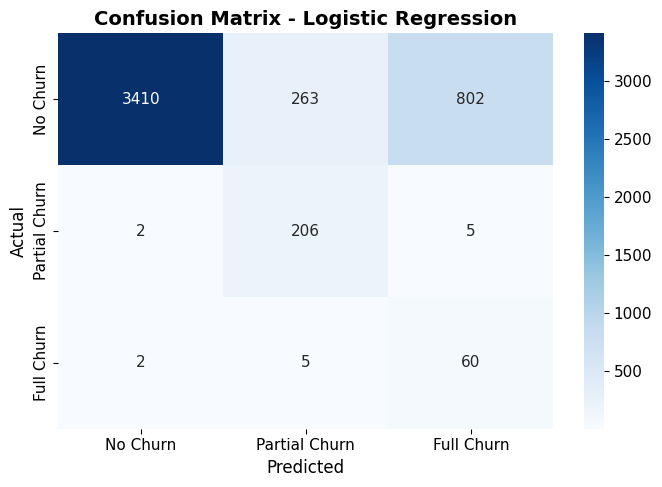

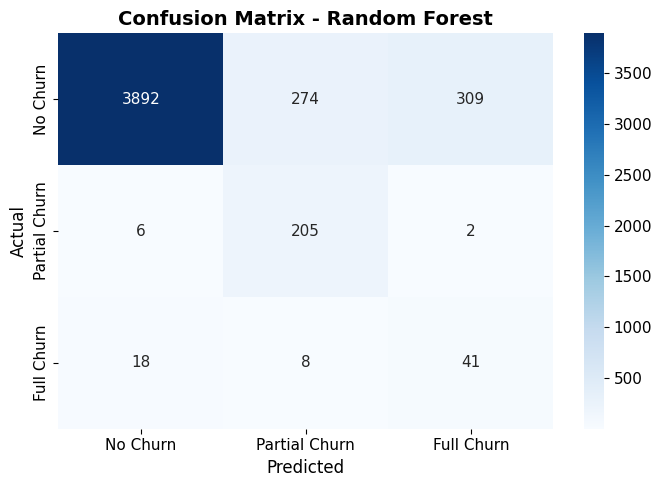

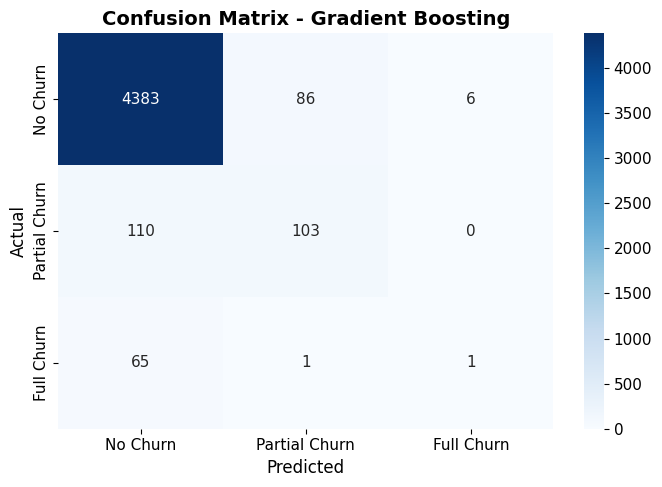

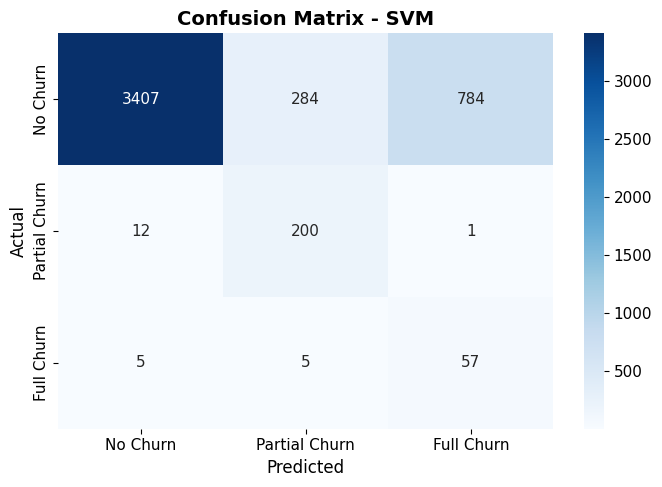

In [7]:
for name, model in models.items():
    evaluation.plot_confusion_matrix(model, X_test_sc, y_test, model_name=name)

## 5.2 ROC Curves (One-vs-Rest)

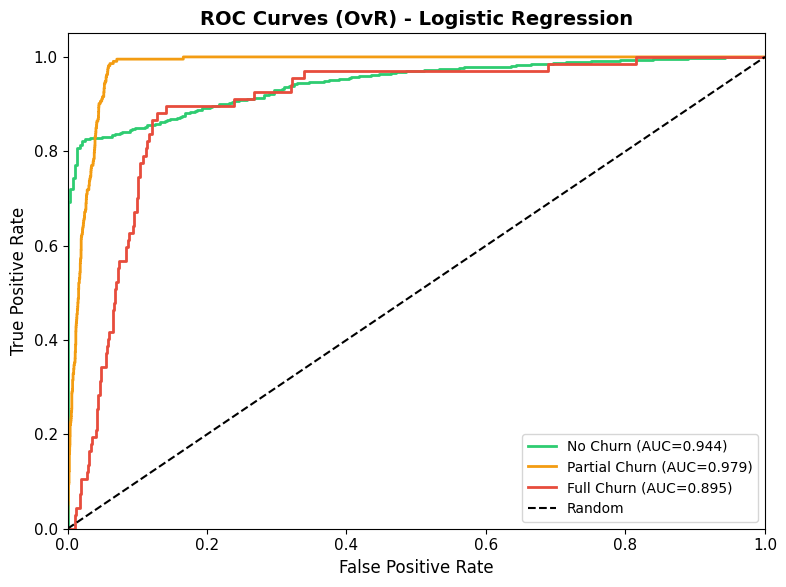

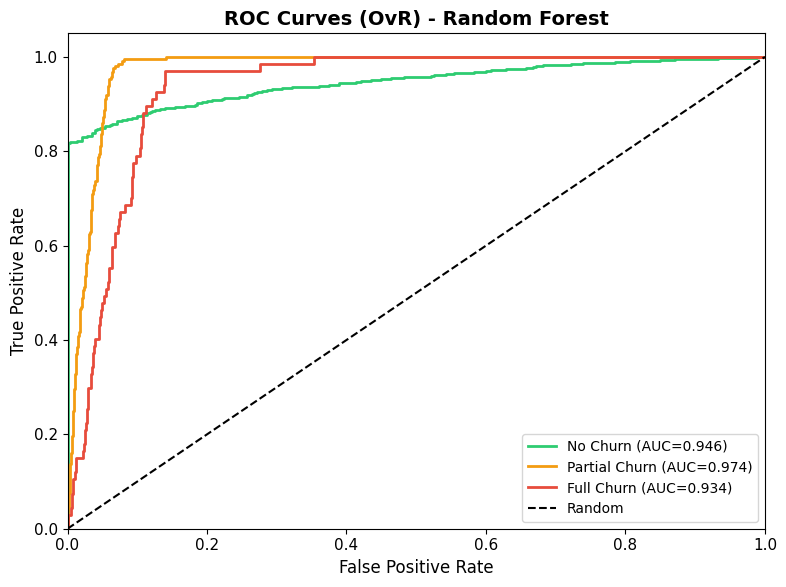

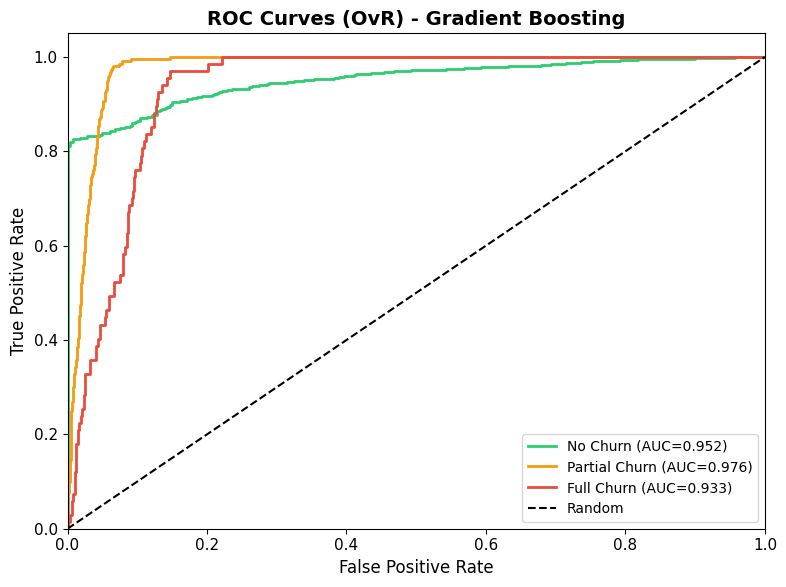

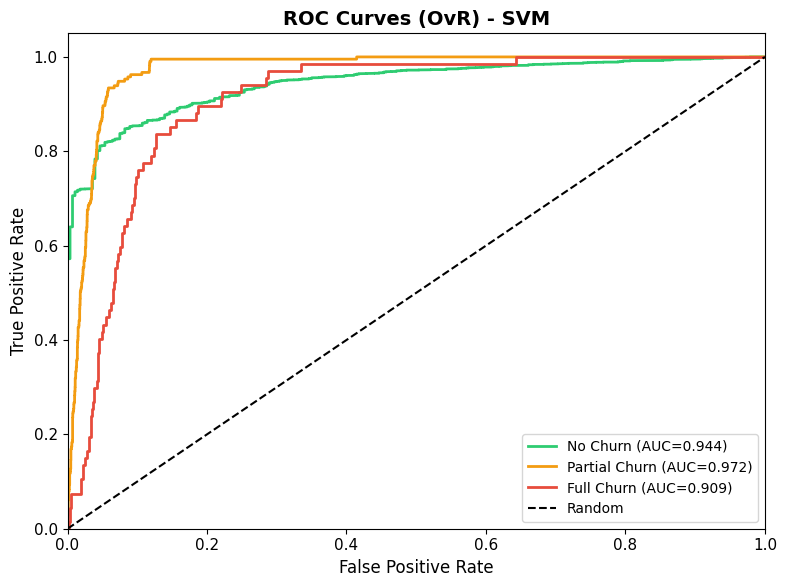

In [8]:
for name, model in models.items():
    evaluation.plot_roc_curves_multiclass(model, X_test_sc, y_test, model_name=name)

---
# 6. Feature Importance

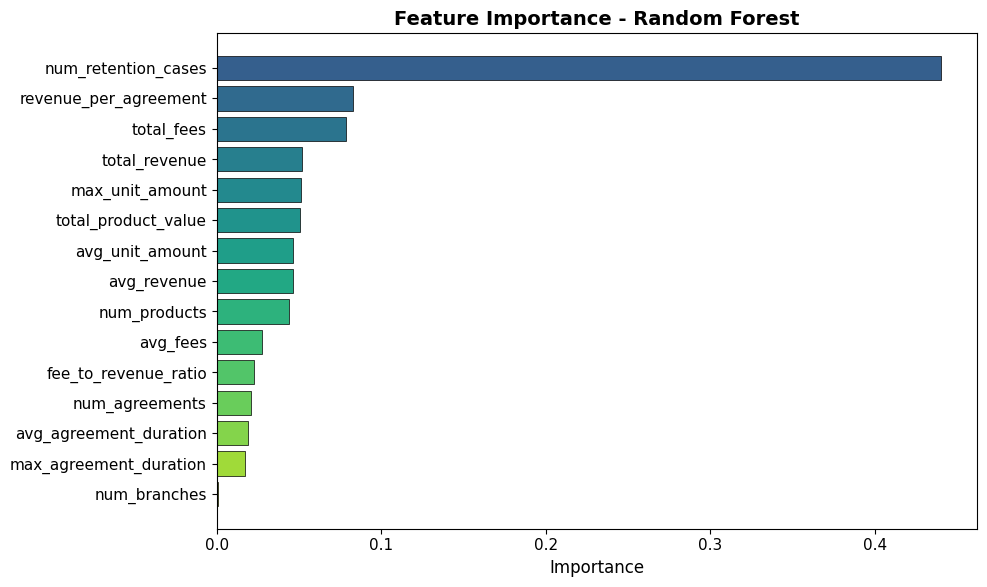

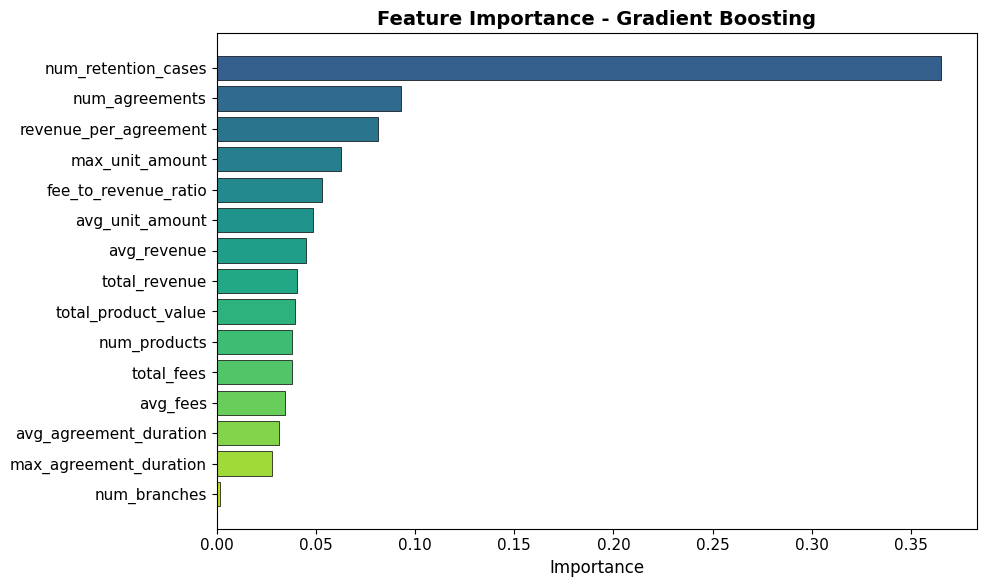

In [9]:
for name in ['Random Forest', 'Gradient Boosting']:
    evaluation.plot_feature_importance(models[name], feature_names, model_name=name)

---
# 7. Model Comparison (Baseline)

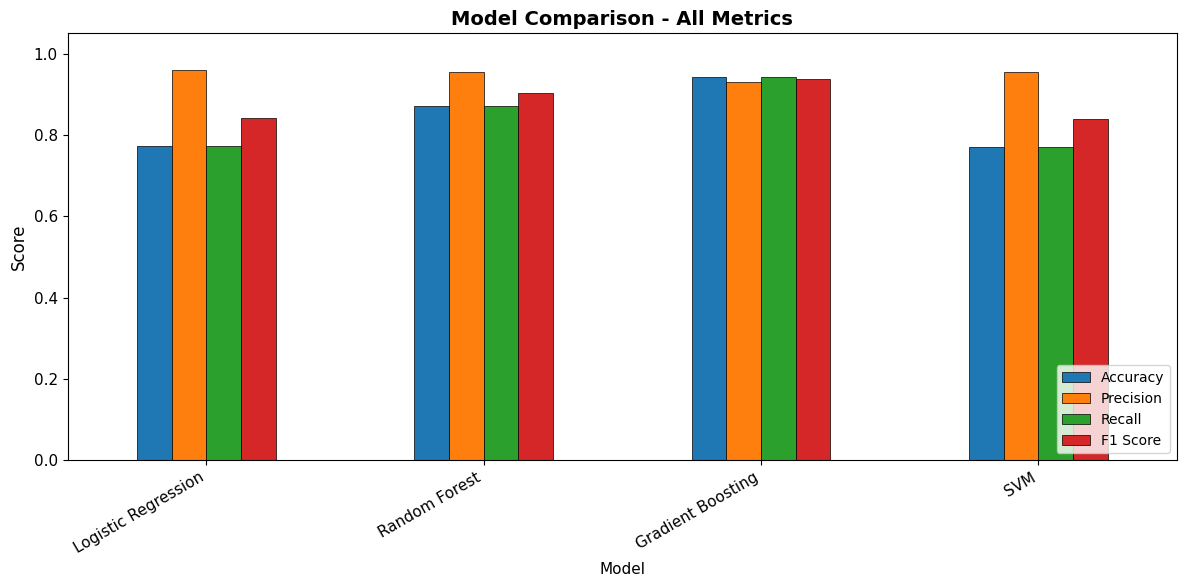

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.773081,0.960455,0.773081,0.842263
Random Forest,0.870242,0.955844,0.870242,0.902030
Gradient Boosting,0.943638,0.931278,0.943638,0.936575
SVM,0.770557,0.955717,0.770557,0.839135


In [10]:
comparison_df = evaluation.compare_models(all_results)
display(comparison_df)

---
# 8. Hyperparameter Tuning

GridSearchCV on Random Forest and Gradient Boosting (5-fold CV, weighted F1).

Tuning Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best RF Params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best RF F1-weighted (CV): 0.9373

  Tuned RF - Evaluation Results
      Accuracy: 0.9262
     Precision: 0.9438
        Recall: 0.9262
      F1 Score: 0.9331

Classification Report:
               precision    recall  f1-score   support

     No Churn       0.98      0.94      0.96      4475
Partial Churn       0.48      0.78      0.60       213
   Full Churn       0.16      0.21      0.18        67

     accuracy                           0.93      4755
    macro avg       0.54      0.65      0.58      4755
 weighted avg       0.94      0.93      0.93      4755



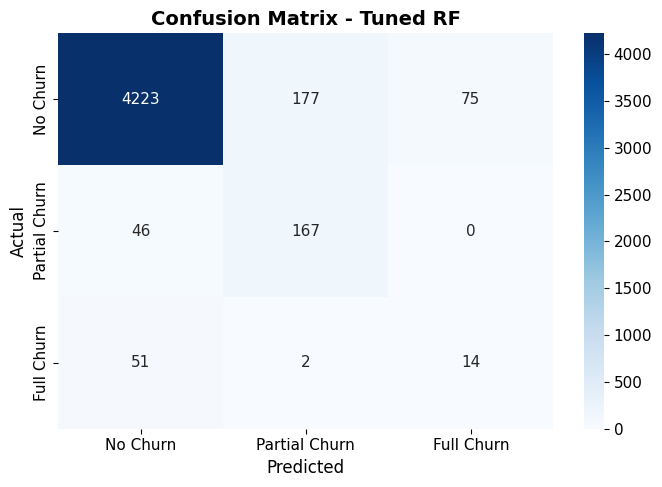

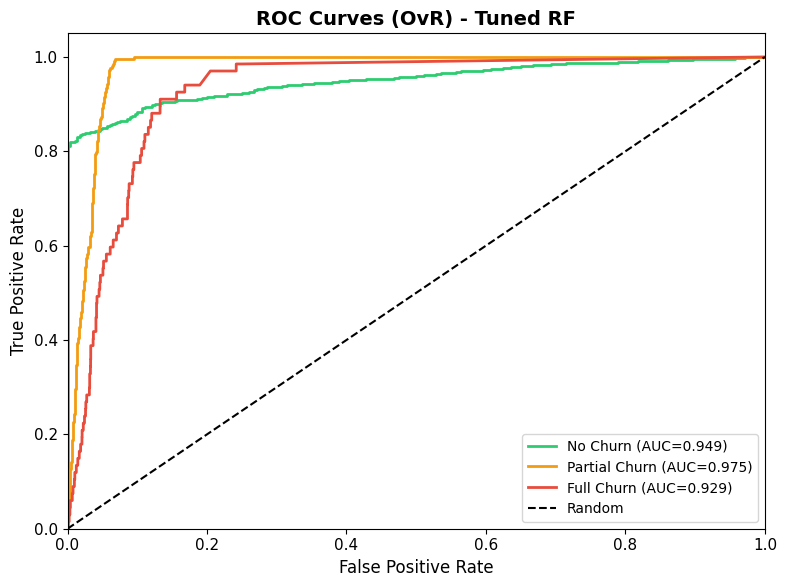

In [11]:
print('Tuning Random Forest...')
best_rf, grid_rf = training.hyperparameter_tune_rf(X_train_sc, y_train, cv=5)
tuned_rf_m = evaluation.evaluate_model(best_rf, X_test_sc, y_test, model_name='Tuned RF')
evaluation.plot_confusion_matrix(best_rf, X_test_sc, y_test, model_name='Tuned RF')
evaluation.plot_roc_curves_multiclass(best_rf, X_test_sc, y_test, model_name='Tuned RF')

Tuning Gradient Boosting...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

Best GB Params: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
Best GB F1-weighted (CV): 0.9407

  Tuned GB - Evaluation Results
      Accuracy: 0.9460
     Precision: 0.9365
        Recall: 0.9460
      F1 Score: 0.9377

Classification Report:
               precision    recall  f1-score   support

     No Churn       0.96      0.98      0.97      4475
Partial Churn       0.57      0.46      0.51       213
   Full Churn       0.50      0.01      0.03        67

     accuracy                           0.95      4755
    macro avg       0.68      0.49      0.50      4755
 weighted avg       0.94      0.95      0.94      4755



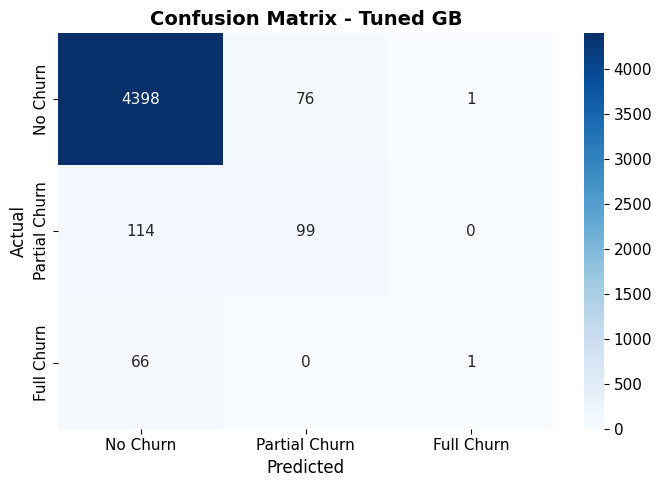

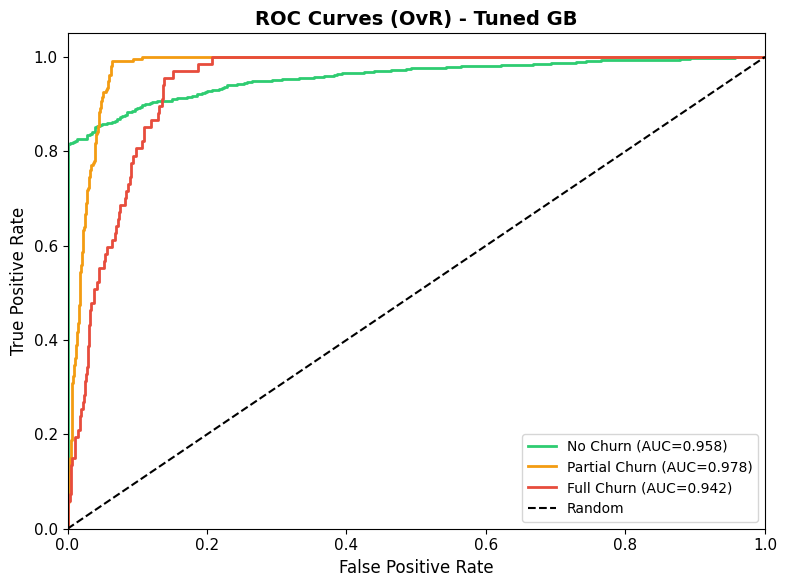

In [12]:
print('Tuning Gradient Boosting...')
best_gb, grid_gb = training.hyperparameter_tune_gb(X_train_sc, y_train, cv=5)
tuned_gb_m = evaluation.evaluate_model(best_gb, X_test_sc, y_test, model_name='Tuned GB')
evaluation.plot_confusion_matrix(best_gb, X_test_sc, y_test, model_name='Tuned GB')
evaluation.plot_roc_curves_multiclass(best_gb, X_test_sc, y_test, model_name='Tuned GB')

## 8.1 Tuned Feature Importance

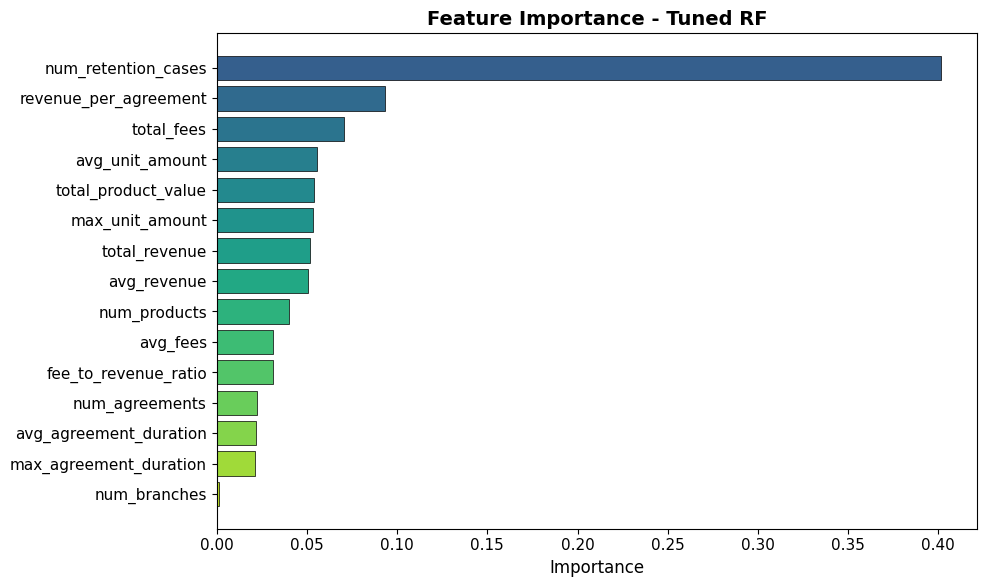

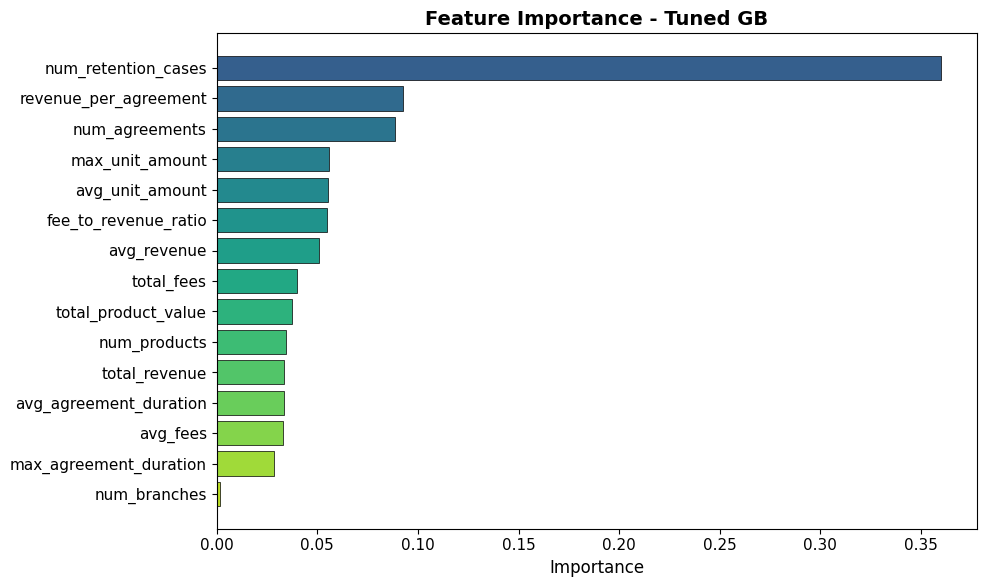

In [13]:
evaluation.plot_feature_importance(best_rf, feature_names, model_name='Tuned RF')
evaluation.plot_feature_importance(best_gb, feature_names, model_name='Tuned GB')

---
# 9. Final Model Comparison

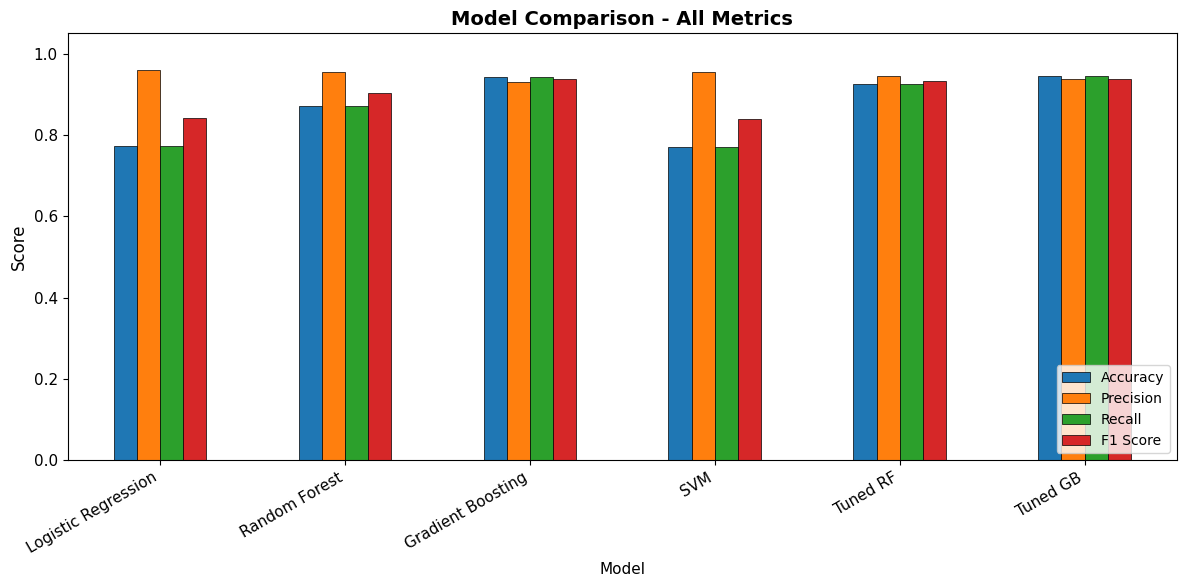

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.773081,0.960455,0.773081,0.842263
Random Forest,0.870242,0.955844,0.870242,0.902030
Gradient Boosting,0.943638,0.931278,0.943638,0.936575
SVM,0.770557,0.955717,0.770557,0.839135
Tuned RF,0.926183,0.943820,0.926183,0.933063
Tuned GB,0.945952,0.936498,0.945952,0.937666


In [14]:
final_results = all_results + [tuned_rf_m, tuned_gb_m]
final_df = evaluation.compare_models(final_results)
display(final_df)

---
# 10. Best Model Selection & Saving

In [15]:
best_idx = max(range(len(final_results)), key=lambda i: final_results[i]['F1 Score'])
best_result = final_results[best_idx]
best_name = best_result['Model']

print(f'\n{"=" * 60}')
print(f'  BEST MODEL: {best_name}')
print(f'{"=" * 60}')
for k, v in best_result.items():
    if k != 'Model':
        print(f'  {k:>12s}: {v:.4f}')

all_models = {**models, 'Tuned RF': best_rf, 'Tuned GB': best_gb}
best_model = all_models[best_name]

evaluation.save_model(best_model, '../../models/best_churn_model.pkl')
print(f'\nModel ({best_name}) saved to models/best_churn_model.pkl')


  BEST MODEL: Tuned GB
      Accuracy: 0.9460
     Precision: 0.9365
        Recall: 0.9460
      F1 Score: 0.9377
Model saved to ../../models/best_churn_model.pkl

Model (Tuned GB) saved to models/best_churn_model.pkl


---
# 11. Conclusion

## Summary
1. Built a **3-class churn prediction model** (No Churn / Partial Churn / Full Churn)
2. Engineered **15+ customer-level features** from BoB data with **no data leakage**
3. Trained and compared **4 classifiers** + hyperparameter tuning
4. Generated comprehensive visualisations: confusion matrices, ROC curves, feature importance
5. Selected and saved the best-performing model

## Business Insights
- Feature importance reveals the key drivers of customer churn
- The model can score new customers for proactive retention campaigns
- Partial churn identification enables early intervention before full loss
